<a href="https://colab.research.google.com/github/wooihaw/k-youth-2603/blob/main/Lab_3/Lab_3c.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lab 3c
#### This dataset comprises 10,000 records, each represented by eight features and one target variable for machine failure. Every entry includes a unique identifier (UID) and a product ID that encodes the variant-specific serial number of the tool. The dataset also captures the tool quality type (L, M, or H), ambient air temperature, and the process temperature measured during operation. Key operational parameters such as rotational speed (rpm), torque (Nm), and accumulated tool wear (minutes) are provided to reflect the mechanical load and degradation conditions. The target column specifies the machine failure status, indicating normal operation (0) or the occurrence of a failure (1). This dataset is suitable for developing and evaluating predictive maintenance models.

In [1]:
# Initialization
%matplotlib inline
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
# Load the required libraries
import pandas as pd
from sklearn.model_selection import train_test_split as split, StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [3]:
# Load the dataset
df = pd.read_csv("https://raw.githubusercontent.com/wooihaw/datasets/main/predictive_maintenance_dataset.csv")

In [4]:
# To do: Print the first 5 rows of data
df.head()

,UID,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0
3,4,L47183,L,298.2,308.6,1433.0,39.5,7,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0


In [5]:
# To do: Check the number of rows and columns
df.shape

(10000, 9)

In [6]:
# To do: Print the descriptive statistics
df.describe()

,UID,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
count,10000.00000,9994.000000,10000.000000,9994.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.005533,310.005560,1538.711427,39.986910,107.951000,0.033900
std,2886.89568,2.000568,1.483734,179.317006,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [7]:
# To do: Check the class breakdown (number of data samples per class)
df.groupby('Machine failure').size()

Machine failure
0    9661
1     339
dtype: int64

In [8]:
# To do: Check the number of missing values for each volumn
df.isna().sum()

UID                        0
Product ID                 0
Type                       0
Air temperature [K]        6
Process temperature [K]    0
Rotational speed [rpm]     6
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
dtype: int64

In [9]:
# To do:
# i. Impute the missing values using statistics if there are any
# ii. Check for any more missing values
df['Air temperature [K]'] = df['Air temperature [K]'].fillna(df['Air temperature [K]'].median())
df['Rotational speed [rpm]'] = df['Rotational speed [rpm]'].fillna(df['Rotational speed [rpm]'].median())
df.isna().sum()

UID                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
dtype: int64

In [10]:
# To do: Check unique categories in the 'Type' column
df['Type'].unique()

array(['M', 'L', 'H'], dtype=object)

In [11]:
# To do:
# i. Define the mapping for the categories in the 'Type' column
# ii. Perform ordinal encoding for the 'Type' column
# iii. Print the first 5 rows of data
type_mapping = {'L':1, 'M':2, 'H':3}
df['Type'] = df['Type'].map(type_mapping)
df.head()

,UID,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,1,M14860,2,298.1,308.6,1551.0,42.8,0,0
1,2,L47181,1,298.2,308.7,1408.0,46.3,3,0
2,3,L47182,1,298.1,308.5,1498.0,49.4,5,0
3,4,L47183,1,298.2,308.6,1433.0,39.5,7,0
4,5,L47184,1,298.2,308.7,1408.0,40.0,9,0


In [12]:
# To do:
# i. Separate to features (X) and target (y), drop any irrelevant columns
# ii. Split to training (80%) and testing (20%) sets using stratified hold-oit validation
X = df.drop(columns=['UID', 'Product ID', 'Machine failure'])
y = df['Machine failure']
X_train, X_test, y_train, y_test = split(X, y, stratify=y, test_size=0.2, random_state=42)

In [13]:
# To do:
# i. Use spotchecking technique to evaluate the performance of kNN, logistic regression, Gaussian naive bayes, support vector machine, decision tree, random forest, gradient boosting trees and MLP classifiers.
# ii. Use stratified k-folds cross-validation with 5 folds.
# iii. Print the mean and standard deviation of the accuracies
models = {}
models['knn'] = KNeighborsClassifier()
models['lgr'] = LogisticRegression()
models['gnb'] = GaussianNB()
models['dtc'] = DecisionTreeClassifier()
models['rfc'] = RandomForestClassifier()
models['svc'] = SVC()
models['gbc'] = GradientBoostingClassifier()
models['mlc'] = MLPClassifier()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for n in models:
    scores = cross_val_score(models[n], X_train, y_train, cv=skf, n_jobs=-1)
    print(f'{n}: {scores.mean():.3%} +/- {scores.std():.3%}')
    

knn: 96.900% +/- 0.129%
lgr: 97.050% +/- 0.222%
gnb: 96.013% +/- 0.127%
dtc: 97.963% +/- 0.308%
rfc: 98.287% +/- 0.166%
svc: 96.613% +/- 0.025%
gbc: 98.175% +/- 0.174%
mlc: 97.062% +/- 0.306%


In [14]:
# To do:
# i. Choose the best performing model
# ii. Train the model using the training set and evaluate its performance using the test set
best_model = RandomForestClassifier(random_state=42).fit(X_train, y_train)
print(f'Best model accuracy: {best_model.score(X_test, y_test):.3%}')

Best model accuracy: 98.450%


In [15]:
# To do: Print the classification report for the best model
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.88      0.63      0.74        68

    accuracy                           0.98      2000
   macro avg       0.93      0.81      0.86      2000
weighted avg       0.98      0.98      0.98      2000



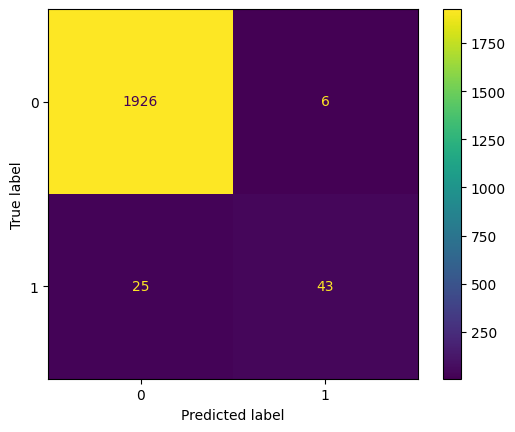

In [16]:
# To do: Plot the confusion matrix of the best model
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

In [18]:
# Use SMOTE from the Imbalanced-learn library to generate syntactic minority samples
from imblearn.over_sampling import SMOTE

# Apply feature scaling
scl = MinMaxScaler()
Xs_train = scl.fit_transform(X_train)
Xs_test = scl.transform(X_test)

# Use SMOTE to oversample the minority class to about 10% of the majority class
smt = SMOTE(sampling_strategy={1:900}, random_state=42)
Xs_train_res, y_train_res = smt.fit_resample(Xs_train, y_train)

In [19]:
# To do:
# i. Train the best model on the resampled training set with feature scaling
# ii. Evaluate its performance on the testing set with feature scaling
best_model = RandomForestClassifier(random_state=42).fit(Xs_train_res, y_train_res)
print(f'Best model accuracy: {best_model.score(Xs_test, y_test):.3%}')

Best model accuracy: 98.450%


In [20]:
# To do: Print the classification report for the best model trained in the previous step
y_pred = best_model.predict(Xs_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.79      0.74      0.76        68

    accuracy                           0.98      2000
   macro avg       0.89      0.86      0.88      2000
weighted avg       0.98      0.98      0.98      2000



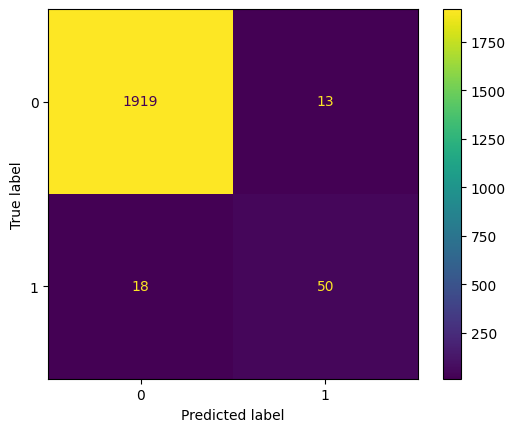

In [21]:
# To do: Plot the confusion matrix of the best model trained in the previous step
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)